# Downsampling Algorithm for EIS data

There are a variety of statistical methods for downsampling timeseries data of various shapes, and yet the peculiar nature of electrochemical impedance spectroscopy data presented an opportunity for further developmment.

Window functions like simple moving averages or largest triangle three buckets are great for densely populated polynomials or otherwise uniformly populated datasets, but fail when considering large enough datasets with extreme minutia, like sparse asymptotes.

### Background and Descriptions

This algorithm targets galvanostatic test data for electrolysis stacks. The galvanostatic test reads data at a low interval, typically just a few seconds, for thousands of hours. The measurements taken are voltage, and current, among other values associated with EIS data.

#### Voltage data
Voltage data is characterized by several segments of data with a slope approximating infinity as a voltage is applied across the electrolysis stack. The performance of the stack degrades over time, showing a slightly negative trend, with many samples also taken at higher or lower voltages.

#### Current data
Current data is characterized by an initial ramp up, and many millions of readings at a constant current. The current changes based on the state of the system, for example whether the stack is heating up, or on load.

### Downsampling

The literature describe a few algoritms designed to downsample timeseries data while preserving their shape. First, the Ramer–Douglas–Peucker algorithm simplifies curves by decimating curves into representative line segments that result in a curve with fewer points. This algorithm however failed to account for the distinct asymptotes in EIS data.

Recent advances in downsampling algorithms for timeseries data from industrial processes have similarly developed a methodology for intelligent downsampling. The multivariate adaptive downsampling algorithm was replicated in Python and applied to sample EIS data, but because EIS data is so densely populated, it fails to interpret any distinct time domains where variance in the data exist. 

## Results
This algorithm uses the `scipy` `argrelextrema` function to calculate relative extrema in the data, neatly identifying variance like asymptotes in EIS data.

In [ ]:
##############################
# DOWNSAMPLING
##############################

import json
import os
import numpy as np
import time as timer

# Target directory for downsampling
fixture_dir = "./FCE/stack1"

anonymized_time = np.array([])
anonymized_voltage = np.array([])
anonymized_current = np.array([])

downsampled_time = np.array([])
downsampled_current = np.array([])
downsampled_voltage = np.array([])

# Downsample to 10,000 points
num_files = len(os.listdir(fixture_dir))
n = 10000 // num_files

for filename in os.listdir(fixture_dir):

    start_time = timer.time()
    
    if filename.endswith(".json"):
        with open(os.path.join(fixture_dir, filename), 'r') as f:
            fixtures = json.load(f)

            time = []
            voltage = []
            current = []

            for obj in fixtures:
                fields = obj['fields']
                data = fields['data']
                time.append(data['time'])
                voltage.append(data['anonymized_voltage'])
                current.append(data['anonymized_current'])

            # Downsample
            time = np.array(time)
            anonymized_time = np.concatenate([anonymized_time, time])
            voltage = np.array(voltage)
            anonymized_voltage = np.concatenate([anonymized_voltage, voltage])
            current = np.array(current)
            anonymized_current = np.concatenate([anonymized_current, current])

            # Detect asymptotes in current and voltage data
            voltage_diff = np.abs(np.gradient(voltage)[1:])
            current_diff = np.abs(np.diff(current))

            voltage_outliers = np.where(voltage_diff > np.percentile(voltage_diff, 95))[0] + 1
            current_outliers = np.where(current_diff > np.percentile(current_diff, 95))[0] + 1

            # Sample 1 of n records across the voltage dataset
            voltage_interp = np.arange(0, len(voltage), n - len(voltage_outliers))
            current_intep = np.arange(0, len(current), n - len(current_outliers))

            # Combine critical indices
            indices = np.concatenate([voltage_outliers, voltage_interp, current_outliers, indices.astype(int)])
            unique = np.unique(indices)

            # Extract downsampled time
            downsampled_time = np.concatenate([downsampled_time, time[unique]])
            downsampled_voltage = np.concatenate([downsampled_voltage, voltage[unique]])
            downsampled_current = np.concatenate([downsampled_current, current[unique]])

            end_time = timer.time()
            print(f"Processed {filename} in {end_time - start_time} seconds")


IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
##############################
# VISUAL COMPARISONS
##############################

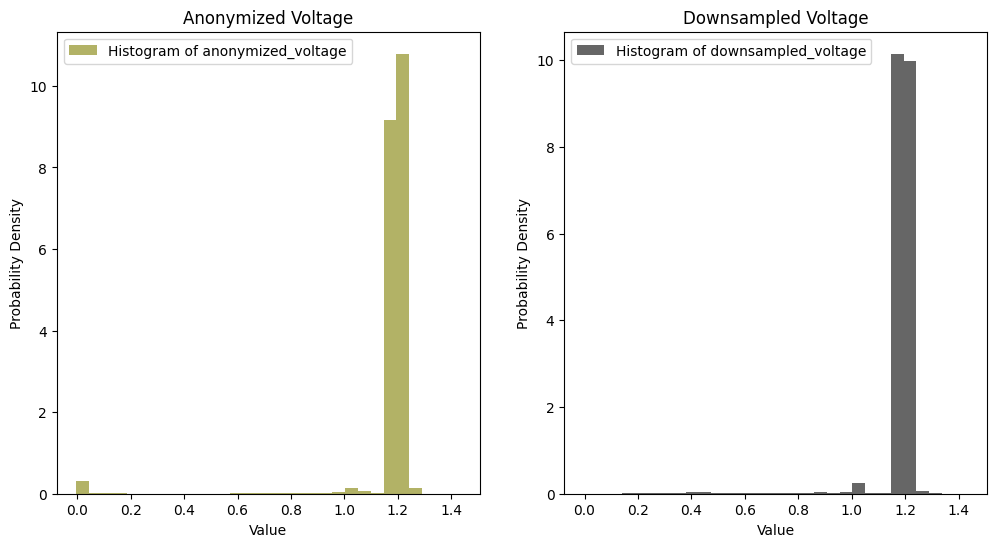

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the histogram of anonymized_voltage in the first subplot
n, bins, patches = axs[0].hist(anonymized_voltage, bins=30, density=True, alpha=0.6, color='olive', label='Histogram of anonymized_voltage')
axs[0].set_title('Anonymized Voltage')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Probability Density')
axs[0].legend()

# Plot the histogram of downsampled_voltage in the second subplot
n, bins, patches = axs[1].hist(downsampled_voltage, bins=30, density=True, alpha=0.6, color='black', label='Histogram of downsampled_voltage')
axs[1].set_title('Downsampled Voltage')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Probability Density')
axs[1].legend()

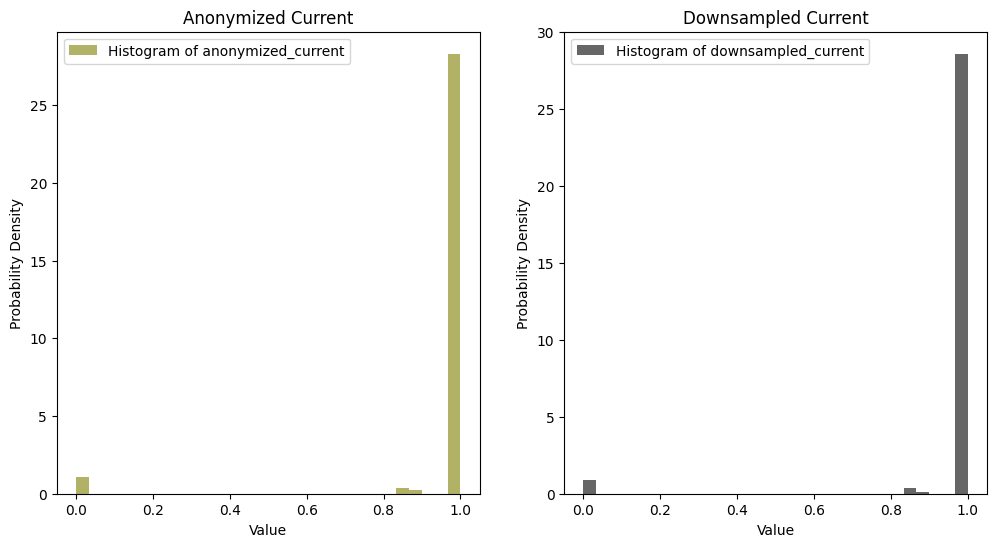

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the histogram of anonymized_voltage in the first subplot
n, bins, patches = axs[0].hist(anonymized_current, bins=30, density=True, alpha=0.6, color='olive', label='Histogram of anonymized_current')
axs[0].set_title('Anonymized Current')
axs[0].set_xlabel('Value')
axs[0].set_ylabel('Probability Density')
axs[0].legend()

# Plot the histogram of downsampled_voltage in the second subplot
n, bins, patches = axs[1].hist(downsampled_current, bins=30, density=True, alpha=0.6, color='black', label='Histogram of downsampled_current')
axs[1].set_title('Downsampled Current')
axs[1].set_xlabel('Value')
axs[1].set_ylabel('Probability Density')
axs[1].legend()

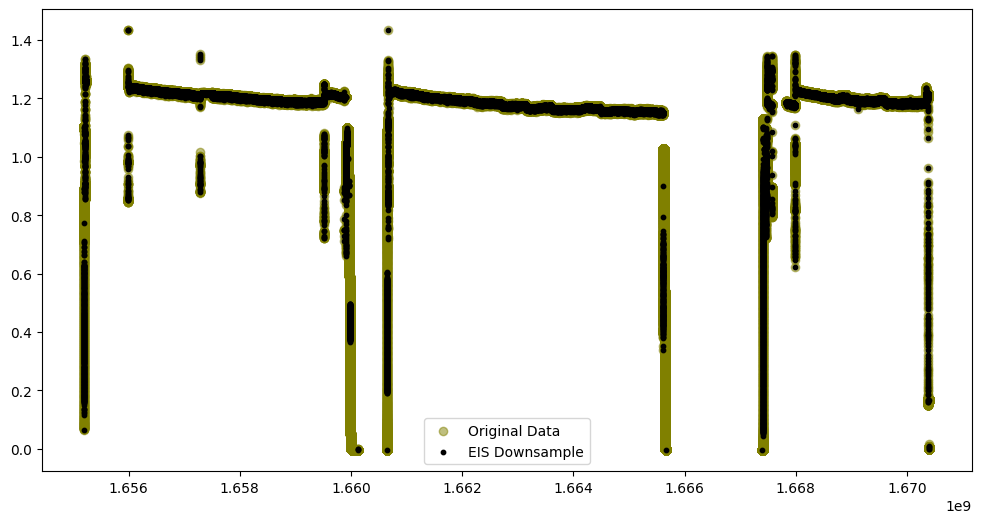

In [ ]:
# Voltage Comparison
plt.figure(figsize=(12, 6))
plt.scatter(anonymized_time, anonymized_voltage, label='Original Data', color='olive', alpha=0.5)
plt.scatter(downsampled_time, downsampled_voltage, label="EIS Downsample", color='black', alpha=1, s=10)
plt.legend(loc="lower center")
plt.show()

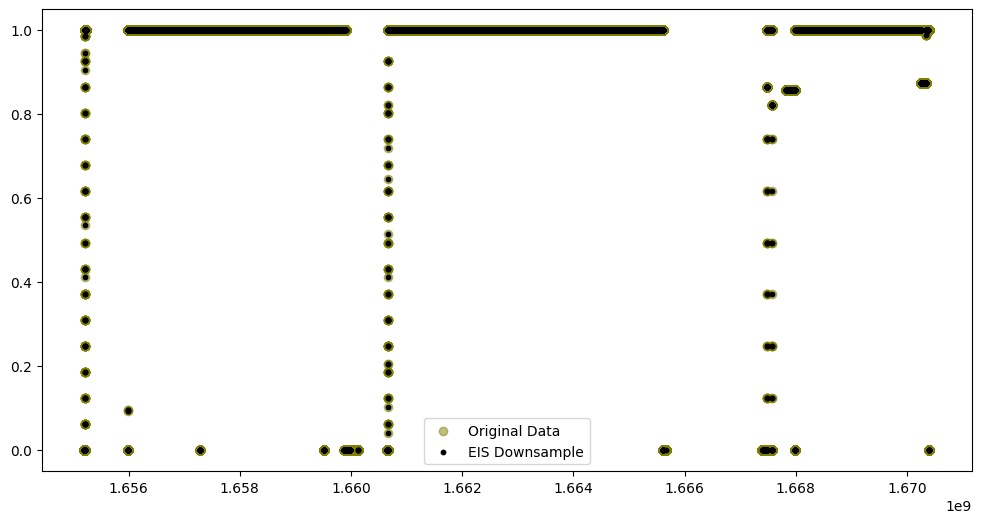

In [ ]:
# Current Comparison
plt.figure(figsize=(12, 6))
plt.scatter(anonymized_time, anonymized_current, label='Original Data', color='olive', alpha=0.5)
plt.scatter(downsampled_time, downsampled_current, label="EIS Downsample", color='black', alpha=1, s=10)
plt.legend(loc="lower center")
plt.show()

In [ ]:
print(f"Current: {len(downsampled_current)}")
print(f"Voltage: {len(downsampled_voltage)}")

Current: 207767
Voltage: 207767
